In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [7]:
data = {
    "Jahr": [2011, 2011, 2012, 2016, 2017, 2019, 2020, 2020, 2021, 2021, 2021, 2021, 2021, 2022, 2022, 2022, 2023, 2023, 2023, 2023, 2023],
    "Modell": ["ERGO", "EliXR", "EliXR-TIME", "Valx", "ElilE", "Criteria2Query (C2Q)", "Clinical Trial Parser", "Ensemble Modell", "ERNI", "MIMO", "RoBERTa", "CT-BERT", "ecBERT", "PubMedBERT", "SciBERT", "C2Q 2.0", "ClinicalTrialBERT", "Expert System", "C2Q 3.0", "AutoCriteria", "LeafAI"],
    "Typ": ["Regelbasierte Parser", "Regelbasierte Parser", "Regelbasierte Parser", "Regelbasierte Parser", "Regelbasierte Parser", "Regelbasierte Parser, ML", "Regelbasierte Parser, ML", "BERT", "ML, BERT", "BERT", "BERT", "BERT", "BERT", "BERT", "BERT", "Regelbasierte Parser, ML", "BERT", "GPT", "ML, GPT", "GPT", "BERT"],
    "Datensatz": ["Manueller Datensatz", "Manueller Datensatz", "Manueller Datensatz", "Manueller Datensatz", "ElilE", "C2Q Datensatz", "FRD", "2019 CHIP", "Manueller Datensatz", "Manueller Datensatz", "Chia, FRD", "FRD", "Chia", "EliIE, Covance, Chia", "LCT", "Covid 19", "PROTECTOR1", "Manueller Datensatz", "Manueller Datensatz", "Manueller Datensatz", "LLF"]
}

In [8]:
farben = {"Regelbasierte Parser": "blue", "ML": "green", "BERT": "red", "GPT": "purple"}
markierungen = {
    "Manueller Datensatz": "o",
    "ElilE": "s",
    "C2Q Datensatz": "D",
    "FRD": "^",
    "2019 CHIP": "<",
    "Chia, FRD": ">",
    "Chia": "p",
    "EliIE, Covance, Chia": "H",
    "LCT": "+",
    "Covid 19": "x",
    "PROTECTOR1": "*",
    "LLF": "|"
}

In [9]:
df = pd.DataFrame(data)

sns.set(style="whitegrid")

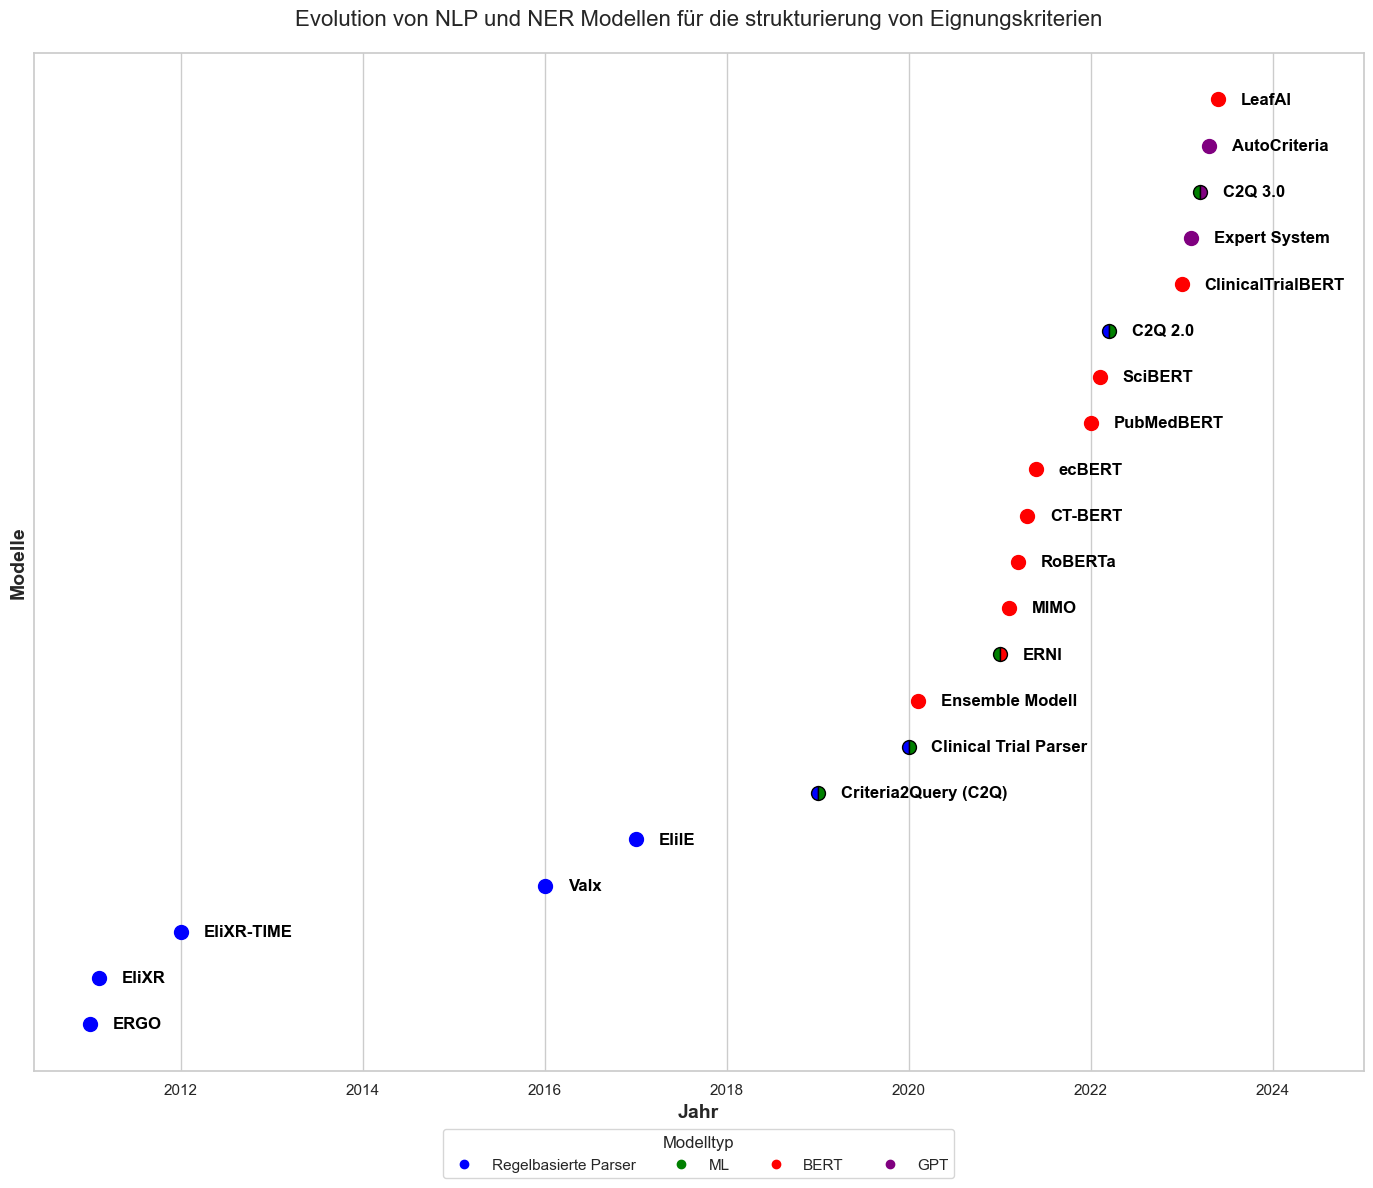

In [10]:
plt.figure(figsize=(14, 12))
verschiebungen = df.groupby('Jahr').cumcount() * 0.1


for (index, row), verschiebung in zip(df.iterrows(), verschiebungen):
    x_wert = row["Jahr"] + verschiebung
    if row["Typ"] == "ML, BERT":
        plt.plot(x_wert, index, marker='o', markersize=10, markerfacecolor=farben["ML"],
                 markerfacecoloralt=farben["BERT"], markeredgewidth=1, markeredgecolor='black',
                 fillstyle='left', linestyle='None')
    if row["Typ"] == "Regelbasierte Parser, ML":
        plt.plot(x_wert, index, marker='o', markersize=10, markerfacecolor=farben["Regelbasierte Parser"],
                 markerfacecoloralt=farben["ML"], markeredgewidth=1, markeredgecolor='black',
                 fillstyle='left', linestyle='None')
    if row["Typ"] == "ML, GPT":
        plt.plot(x_wert, index, marker='o', markersize=10, markerfacecolor=farben["ML"],
                 markerfacecoloralt=farben["GPT"], markeredgewidth=1, markeredgecolor='black',
                 fillstyle='left', linestyle='None')
    else:
        plt.scatter(x_wert, index, color=farben.get(row["Typ"], "white"), marker='o', s=100)
    plt.text(x_wert + 0.25, index, f"{row['Modell']}", verticalalignment='center', horizontalalignment='left', fontsize=12,  color='black', weight='bold')

plt.xlabel("Jahr", fontsize=14, weight='bold')
plt.ylabel("Modelle", fontsize=14, weight='bold')
plt.yticks([])
plt.title("Evolution von NLP und NER Modellen für die strukturierung von Eignungskriterien", fontsize=16, pad=20)
plt.grid(True)
plt.xlim(right=2025)
typ_legend = [plt.Line2D([0], [0], color=color, marker='o', linestyle='', label=typ) for typ, color in farben.items()]
plt.legend(handles=typ_legend, title="Modelltyp", loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=5)

plt.tight_layout()
plt.savefig("./pics/evolution_modelle.png")
plt.savefig("./pics/evolution_modelle.svg", format='svg')

plt.show()